In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
print(df['customerID'])

0       7590-VHVEG
1       5575-GNVDE
2       3668-QPYBK
3       7795-CFOCW
4       9237-HQITU
           ...    
7038    6840-RESVB
7039    2234-XADUH
7040    4801-JZAZL
7041    8361-LTMKD
7042    3186-AJIEK
Name: customerID, Length: 7043, dtype: object


In [ ]:
import pandas as pd
import numpy as np

# Number of fake rows
n = 32957

# Generate fake dataset
fake_data = pd.DataFrame({
    'customerID': [f"ID{i:05d}" for i in range(n)],
    'gender': np.random.choice(['Male', 'Female'], size=n),
    'SeniorCitizen': np.random.choice([0, 1], size=n),
    'Partner': np.random.choice(['Yes', 'No'], size=n),
    'Dependents': np.random.choice(['Yes', 'No'], size=n),
    'tenure': np.random.randint(0, 72, size=n),  # tenure usually 0–72 months
    'PhoneService': np.random.choice(['Yes', 'No'], size=n),
    'MultipleLines': np.random.choice(['Yes', 'No', 'No phone service'], size=n),
    'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], size=n),
    'OnlineSecurity': np.random.choice(['Yes', 'No', 'No internet service'], size=n),
    'OnlineBackup': np.random.choice(['Yes', 'No', 'No internet service'], size=n),
    'DeviceProtection': np.random.choice(['Yes', 'No', 'No internet service'], size=n),
    'TechSupport': np.random.choice(['Yes', 'No', 'No internet service'], size=n),
    'StreamingTV': np.random.choice(['Yes', 'No', 'No internet service'], size=n),
    'StreamingMovies': np.random.choice(['Yes', 'No', 'No internet service'], size=n),
    'Contract': np.random.choice(['Month-to-month', 'One year', 'Two year'], size=n),
    'PaperlessBilling': np.random.choice(['Yes', 'No'], size=n),
    'PaymentMethod': np.random.choice([
        'Electronic check', 'Mailed check',
        'Bank transfer (automatic)', 'Credit card (automatic)'
    ], size=n),
    'MonthlyCharges': np.round(np.random.uniform(18, 120, size=n), 2),  # realistic range
    'TotalCharges': np.round(np.random.uniform(18, 8000, size=n), 2).astype(str),  # keep as string
    'Churn': np.random.choice(['Yes', 'No'], size=n)
})

# Append to your original dataset
df = pd.concat([df, fake_data], ignore_index=True)

print("Dataset size after adding fake values:", len(df))


Dataset size after adding fake values: 40000


In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,40000.000000,40000.000000,40000.000000
mean,0.439450,34.970425,68.257283
std,0.496326,21.518931,29.628377
min,0.000000,0.000000,18.000000
25%,0.000000,16.000000,43.030000
50%,0.000000,35.000000,69.530000
75%,1.000000,54.000000,93.700000
max,1.000000,72.000000,120.000000


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
df.shape

(40000, 21)

In [ ]:
df[df.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [ ]:
df['customerID'].value_counts()

,count
customerID,
ID32940,1
ID32939,1
ID32938,1
ID32937,1
ID32936,1
...,...
9237-HQITU,1
7795-CFOCW,1
3668-QPYBK,1


In [ ]:
print(df)

       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0      7590-VHVEG  Female              0     Yes         No       1   
1      5575-GNVDE    Male              0      No         No      34   
2      3668-QPYBK    Male              0      No         No       2   
3      7795-CFOCW    Male              0      No         No      45   
4      9237-HQITU  Female              0      No         No       2   
...           ...     ...            ...     ...        ...     ...   
39995     ID32952    Male              1     Yes        Yes      41   
39996     ID32953  Female              0      No         No      66   
39997     ID32954  Female              0     Yes         No       9   
39998     ID32955  Female              0      No        Yes      13   
39999     ID32956  Female              0      No        Yes       6   

      PhoneService     MultipleLines InternetService       OnlineSecurity  \
0               No  No phone service             DSL                  

In [ ]:
df['customerID'].unique()

array(['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', ..., 'ID32954',
       'ID32955', 'ID32956'], dtype=object)

In [ ]:
df['gender'].unique()


array(['Female', 'Male'], dtype=object)

In [ ]:
df['SeniorCitizen'].unique()

array([0, 1])

In [ ]:
df['Partner'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['Dependents'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39])

In [ ]:
df['PhoneService'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df['MultipleLines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [ ]:
df['InternetService'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [ ]:
df['OnlineSecurity'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
df['OnlineBackup'].unique()

array(['Yes', 'No', 'No internet service'], dtype=object)

In [ ]:
df['DeviceProtection'].unique()


array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
df['TechSupport'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
df['StreamingTV'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
df['StreamingMovies'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [ ]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [ ]:
df['PaperlessBilling'].unique()

array(['Yes', 'No'], dtype=object)

In [ ]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '947.78', '5195.25', '127.35'],
      dtype=object)

In [ ]:
df['MonthlyCharges'].unique()

array([29.85, 56.95, 53.85, ..., 34.28, 84.93, 68.93])

In [ ]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [ ]:
df.to_csv("Telco-Customer-Churn.csv", index=False)

In [ ]:
from google.colab import files

# Replace with the name of your CSV file
files.download("Telco-Customer-Churn.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_553/1253057142.py:6: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Telco-Customer-Churn.csv")
/tmp/ipykernel_553/1253057142.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="Set2")


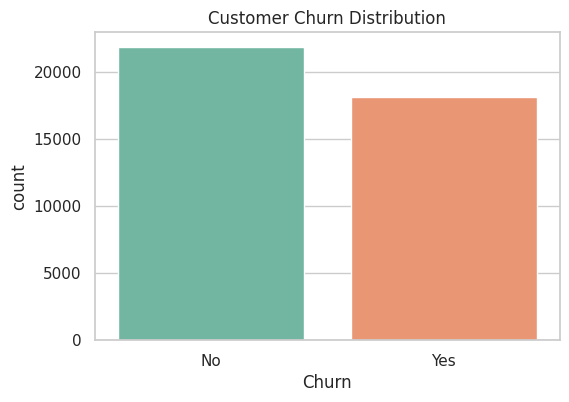

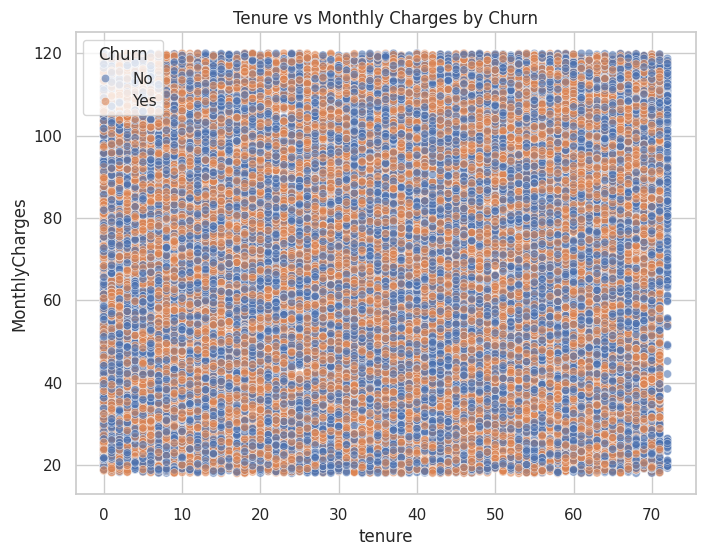

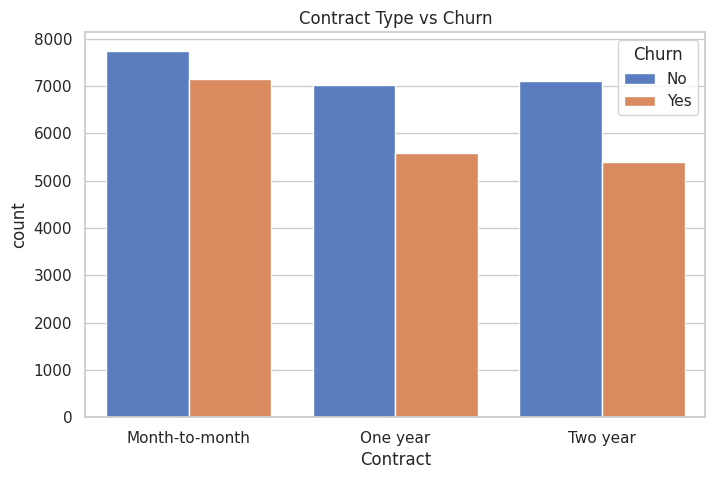

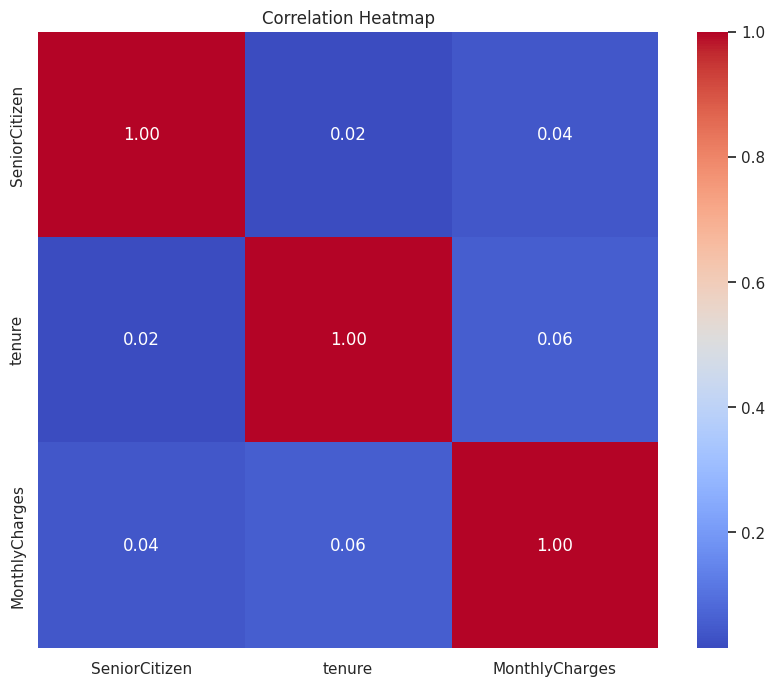

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your cleaned dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Set a professional style
sns.set_theme(style="whitegrid")

# 1. Distribution of Churn
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Customer Churn Distribution")
plt.show()

# 2. Tenure vs Monthly Charges (colored by Churn)
plt.figure(figsize=(8,6))
sns.scatterplot(x="tenure", y="MonthlyCharges", hue="Churn", data=df, alpha=0.6)
plt.title("Tenure vs Monthly Charges by Churn")
plt.show()

# 3. Contract Type vs Churn
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df, palette="muted")
plt.title("Contract Type vs Churn")
plt.show()

# 4. Heatmap of correlations (numeric features only)
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=["float64","int64"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


/tmp/ipykernel_553/1755608686.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="Set2")


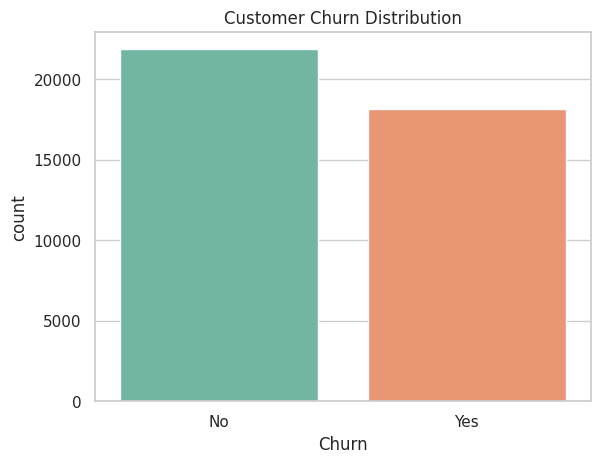

/tmp/ipykernel_553/1755608686.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="gender", data=df, palette="pastel")


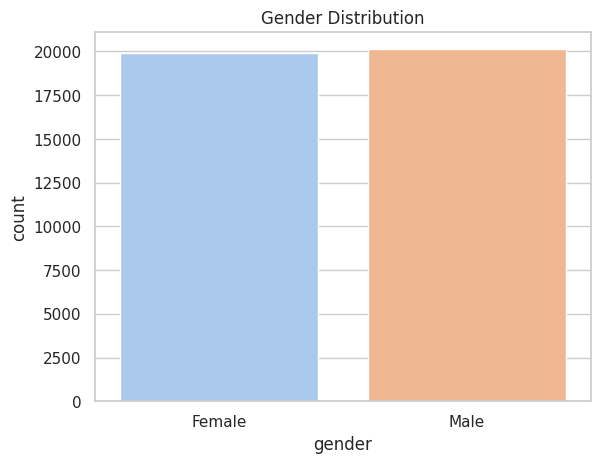

/tmp/ipykernel_553/1755608686.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="InternetService", data=df, palette="muted")


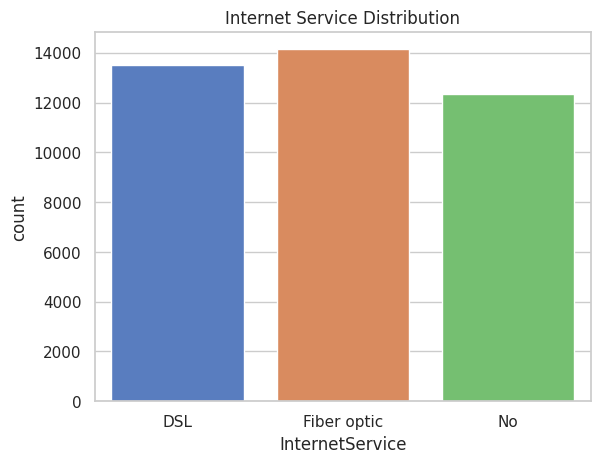

In [ ]:
# Churn distribution
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Customer Churn Distribution")
plt.show()

# Gender distribution
sns.countplot(x="gender", data=df, palette="pastel")
plt.title("Gender Distribution")
plt.show()

# Internet service distribution
sns.countplot(x="InternetService", data=df, palette="muted")
plt.title("Internet Service Distribution")
plt.show()


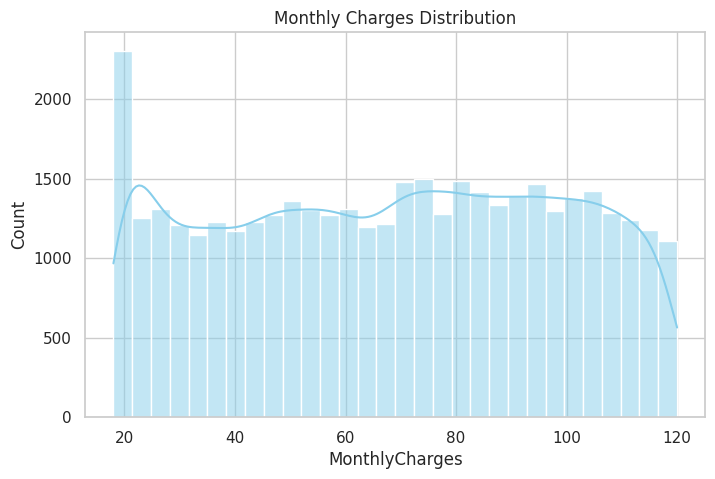

/tmp/ipykernel_553/1814033443.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="Set1")


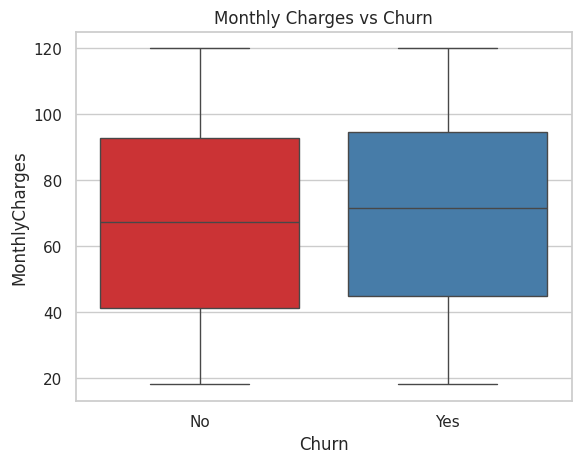

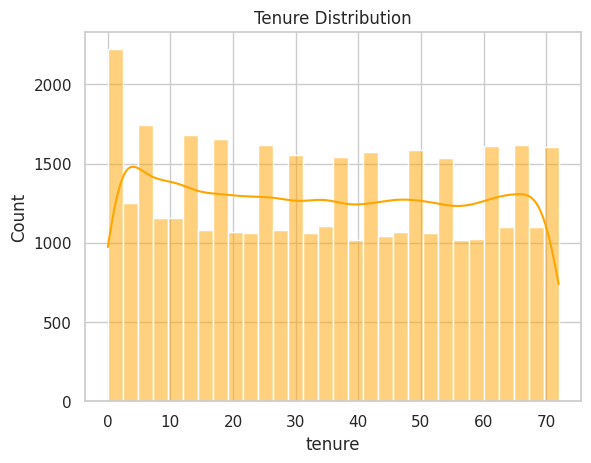

In [ ]:
# Histogram of Monthly Charges
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True, color="skyblue")
plt.title("Monthly Charges Distribution")
plt.show()

# Boxplot of Monthly Charges by Churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="Set1")
plt.title("Monthly Charges vs Churn")
plt.show()

# Tenure distribution
sns.histplot(df["tenure"], bins=30, kde=True, color="orange")
plt.title("Tenure Distribution")
plt.show()


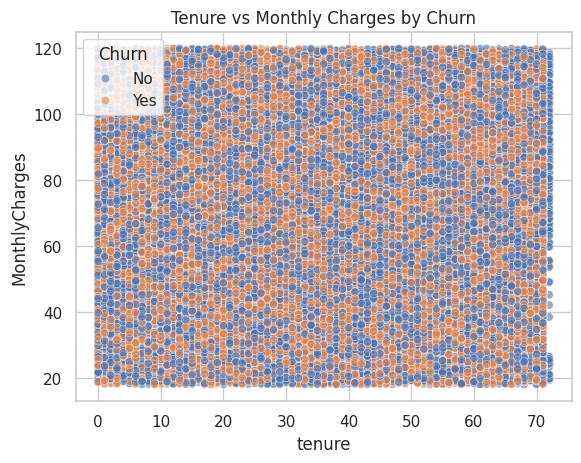

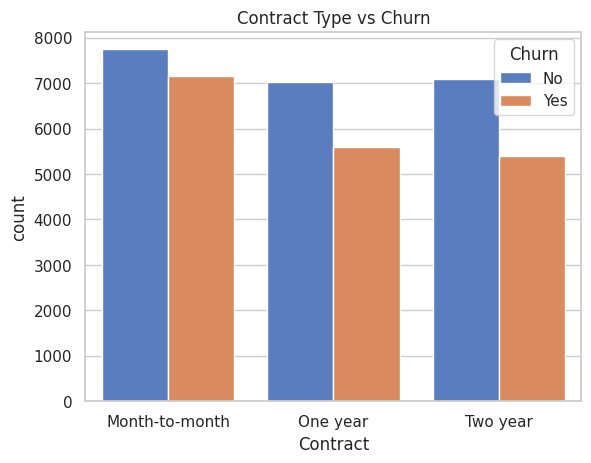

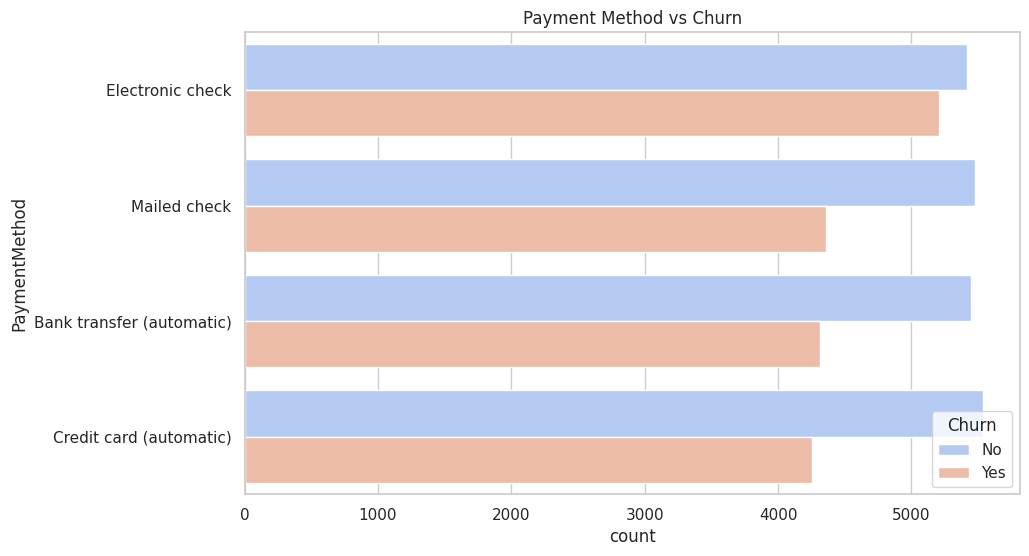

In [ ]:
# Tenure vs Monthly Charges by Churn
sns.scatterplot(x="tenure", y="MonthlyCharges", hue="Churn", data=df, alpha=0.6)
plt.title("Tenure vs Monthly Charges by Churn")
plt.show()

# Contract type vs Churn
sns.countplot(x="Contract", hue="Churn", data=df, palette="muted")
plt.title("Contract Type vs Churn")
plt.show()

# Payment Method vs Churn
plt.figure(figsize=(10,6))
sns.countplot(y="PaymentMethod", hue="Churn", data=df, palette="coolwarm")
plt.title("Payment Method vs Churn")
plt.show()


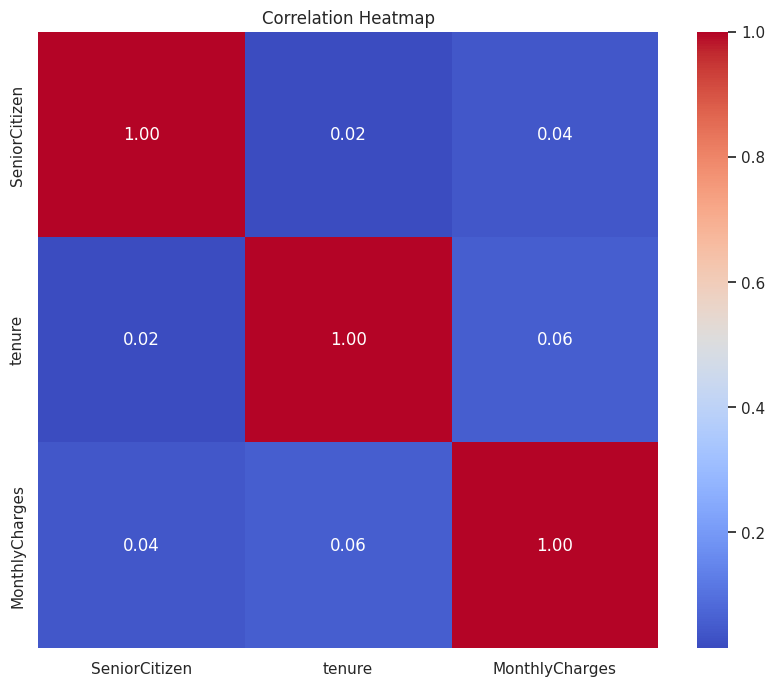

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,8))
corr = df.select_dtypes(include=["float64","int64"]).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


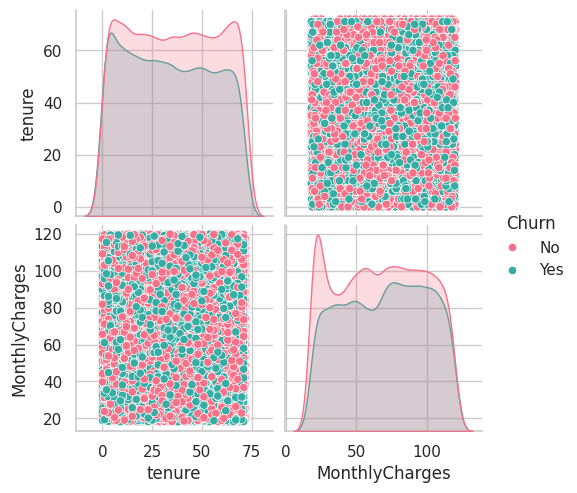

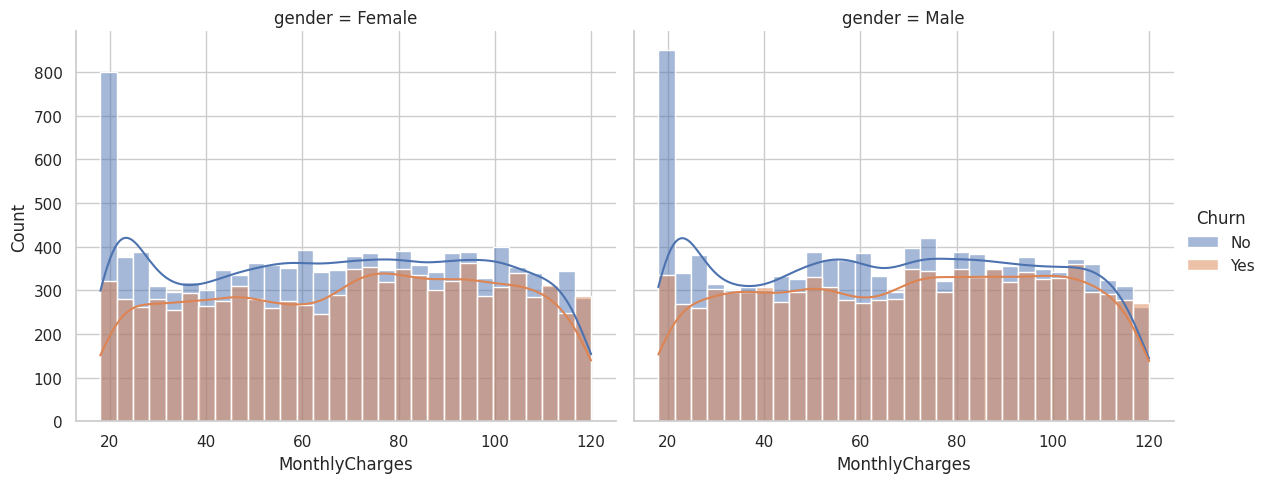

/tmp/ipykernel_553/1621956524.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df["Churn"]=="No","tenure"], label="No Churn", shade=True)
/tmp/ipykernel_553/1621956524.py:13: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df.loc[df["Churn"]=="Yes","tenure"], label="Churn", shade=True)


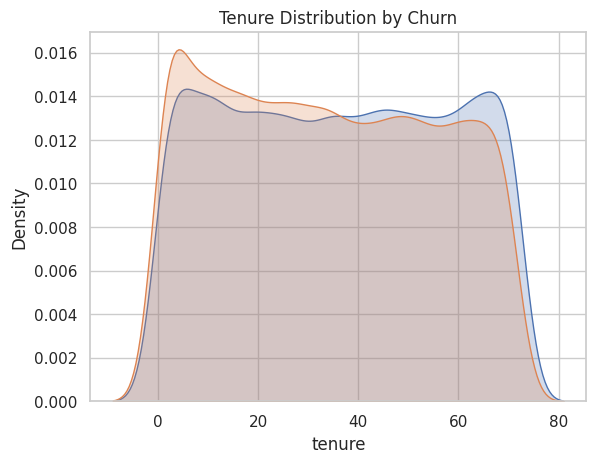

In [ ]:
# Pairplot for selected features
sns.pairplot(df[["tenure","MonthlyCharges","TotalCharges","Churn"]], hue="Churn", palette="husl")
plt.show()

# Facet grid: churn by gender
g = sns.FacetGrid(df, col="gender", hue="Churn", height=5, aspect=1.2)
g.map(sns.histplot, "MonthlyCharges", bins=30, kde=True)
g.add_legend()
plt.show()

# Survival curve style: tenure vs churn
sns.kdeplot(df.loc[df["Churn"]=="No","tenure"], label="No Churn", shade=True)
sns.kdeplot(df.loc[df["Churn"]=="Yes","tenure"], label="Churn", shade=True)
plt.title("Tenure Distribution by Churn")
plt.show()


In [ ]:
import plotly.express as px

fig = px.scatter(df, x="tenure", y="MonthlyCharges", color="Churn",
                 title="Tenure vs Monthly Charges by Churn")
fig.show()


In [ ]:
df["ARPU"] = df["MonthlyCharges"] / df["tenure"].replace(0,1)



In [ ]:
df["CLV"] = df["MonthlyCharges"] * df["tenure"]


In [ ]:
df["TenureGroup"] = pd.cut(df["tenure"], bins=[0,12,24,48,72],
                           labels=["0-12","12-24","24-48","48-72"])


In [ ]:
# --- Feature Engineering ---

# 1. Customer Lifetime Value (CLV)
df["CLV"] = df["MonthlyCharges"] * df["tenure"]

# 2. Average Revenue Per User (ARPU)
df["ARPU"] = df["MonthlyCharges"] / df["tenure"].replace(0,1)

# 3. Tenure Group (categorical buckets)
df["TenureGroup"] = pd.cut(df["tenure"],
                           bins=[0,12,24,48,72],
                           labels=["0-12","12-24","24-48","48-72"])

# --- Checking the new features ---
print("CLV values:\n", df["CLV"].head())
print("\nARPU values:\n", df["ARPU"].head())
print("\nTenureGroup unique values:\n", df["TenureGroup"].unique())
print("\nTenureGroup counts:\n", df["TenureGroup"].value_counts())


CLV values:
 0      29.85
1    1936.30
2     107.70
3    1903.50
4     141.40
Name: CLV, dtype: float64

ARPU values:
 0    29.850
1     1.675
2    26.925
3     0.940
4    35.350
Name: ARPU, dtype: float64

TenureGroup unique values:
 ['0-12', '24-48', '12-24', '48-72', NaN]
Categories (4, object): ['0-12' < '12-24' < '24-48' < '48-72']

TenureGroup counts:
 TenureGroup
48-72    12714
24-48    12658
0-12      7682
12-24     6491
Name: count, dtype: int64


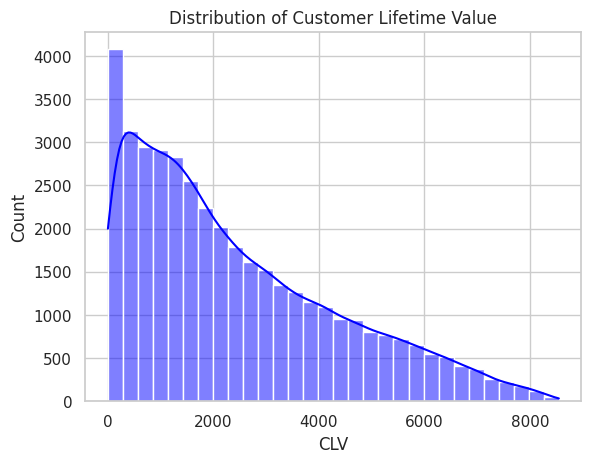

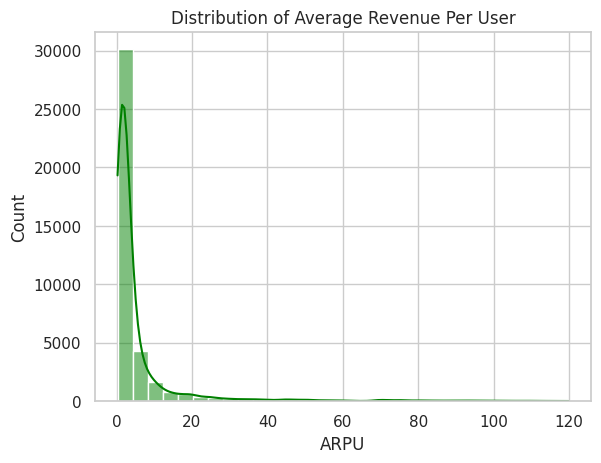

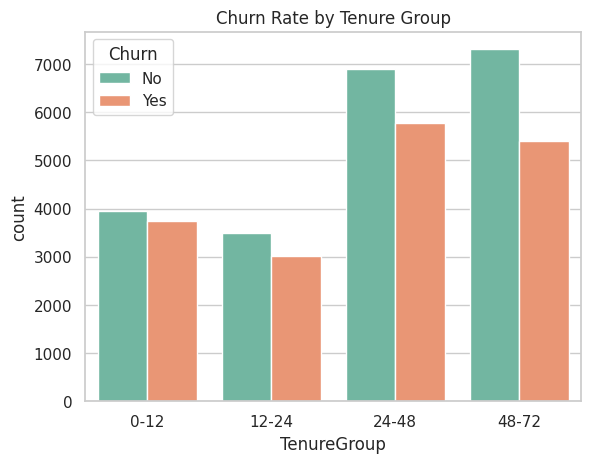

In [ ]:
# CLV distribution
sns.histplot(df["CLV"], bins=30, kde=True, color="blue")
plt.title("Distribution of Customer Lifetime Value")
plt.show()

# ARPU distribution
sns.histplot(df["ARPU"], bins=30, kde=True, color="green")
plt.title("Distribution of Average Revenue Per User")
plt.show()

# TenureGroup vs Churn
sns.countplot(x="TenureGroup", hue="Churn", data=df, palette="Set2")
plt.title("Churn Rate by Tenure Group")
plt.show()


In [ ]:
df.drop("customerID", axis=1, inplace=True)

In [ ]:
df["gender"] = df["gender"].map({"Female":0,"Male":1})

In [ ]:
df["Partner"] = df["Partner"].map({"No":0,"Yes":1})

In [ ]:
df["Dependents"] = df["Dependents"].map({"No":0,"Yes":1})

In [ ]:
df["PhoneService"] = df["PhoneService"].map({"No":0,"Yes":1})

In [ ]:
df["MultipleLines"] = df["MultipleLines"].replace("No phone service","No")

In [ ]:
df["InternetService"] = df["InternetService"].map({"DSL":0,"Fiber optic":1,"No":2})


In [ ]:
cols = [
"OnlineSecurity",
"OnlineBackup",
"DeviceProtection",
"TechSupport",
"StreamingTV",
"StreamingMovies"
]

for col in cols:
    df[col] = df[col].replace("No internet service","No1")
    df[col] = df[col].map({"Yes":0,"No":1,"No1":2})

In [ ]:
cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Replace "No internet service" with "No1"
for col in cols:
    df[col] = df[col].replace("No internet service", "No1")

# Map values to numeric
for col in cols:
    df[col] = df[col].map({"Yes": 1, "No": 0, "No1": 2})

# Check unique values after mapping
for col in cols:
    print(col, df[col].unique())


OnlineSecurity [nan]
OnlineBackup [nan]
DeviceProtection [nan]
TechSupport [nan]
StreamingTV [nan]
StreamingMovies [nan]


In [ ]:
contract_map = {
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2
}
df["Contract_encoded"] = df["Contract"].map(contract_map)


In [ ]:
df["PaperlessBilling"] = df["PaperlessBilling"].map({"No":0,"Yes":1})

In [ ]:
df_encoded = pd.get_dummies(df, columns=["PaymentMethod"], drop_first=True)

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
df["Churn"] = df["Churn"].map({"No":0,"Yes":1})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            40000 non-null  int64   
 1   SeniorCitizen     40000 non-null  int64   
 2   Partner           40000 non-null  int64   
 3   Dependents        40000 non-null  int64   
 4   tenure            40000 non-null  int64   
 5   PhoneService      40000 non-null  int64   
 6   MultipleLines     40000 non-null  object  
 7   InternetService   40000 non-null  int64   
 8   OnlineSecurity    0 non-null      float64 
 9   OnlineBackup      0 non-null      float64 
 10  DeviceProtection  0 non-null      float64 
 11  TechSupport       0 non-null      float64 
 12  StreamingTV       0 non-null      float64 
 13  StreamingMovies   0 non-null      float64 
 14  Contract          40000 non-null  object  
 15  PaperlessBilling  40000 non-null  int64   
 16  PaymentMethod     4000

In [ ]:
# Save the cleaned dataframe to a CSV file
df.to_csv("cleaned_telco_churn.csv", index=False)

# If you're in Google Colab, download the file to your local machine
from google.colab import files
files.download("cleaned_telco_churn.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

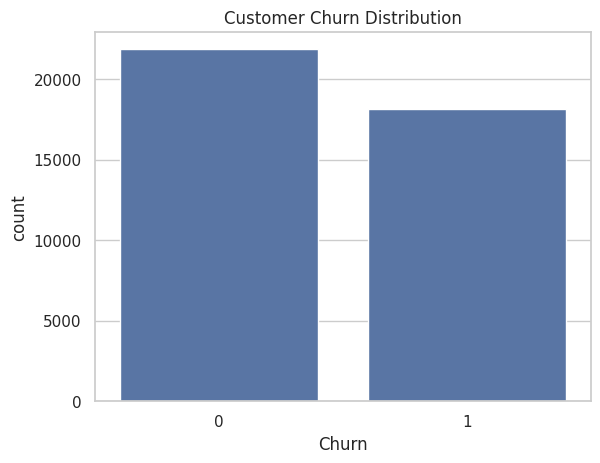

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

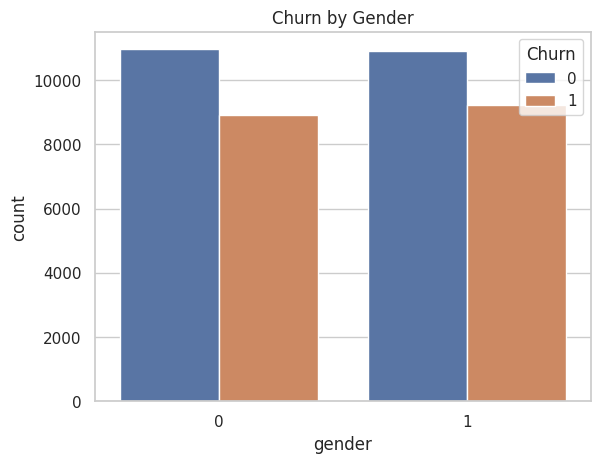

In [ ]:
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Churn by Gender")
plt.show()

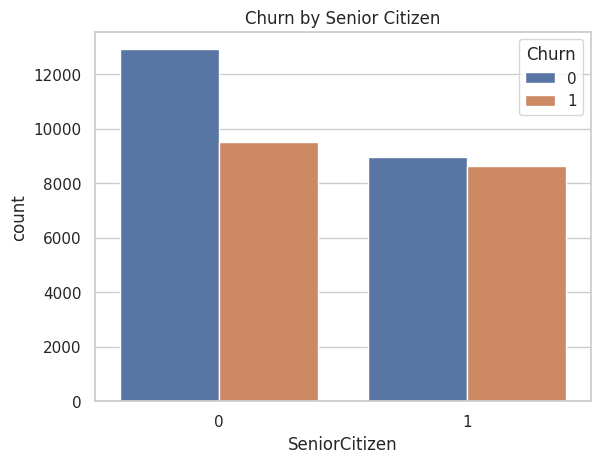

In [ ]:
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)
plt.title("Churn by Senior Citizen")
plt.show()

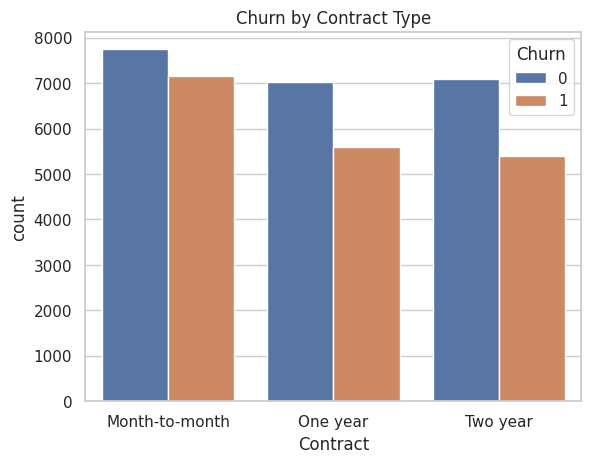

In [ ]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.show()

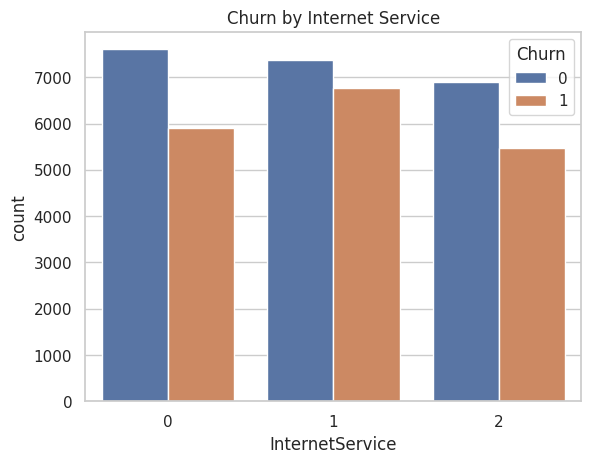

In [ ]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Churn by Internet Service")
plt.show()

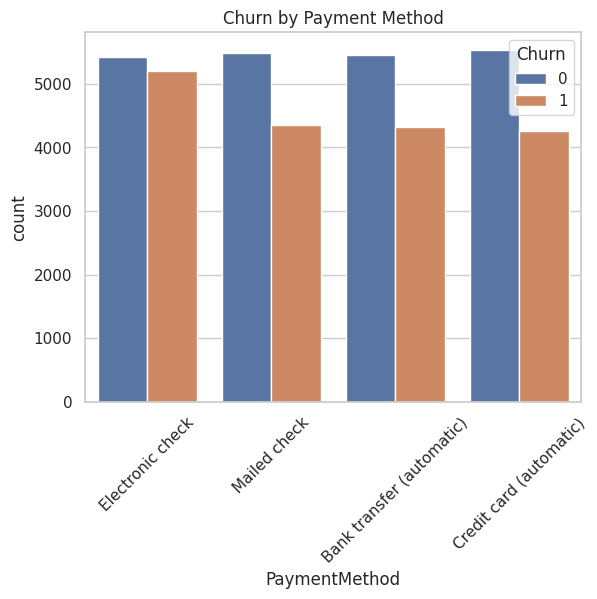

In [ ]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

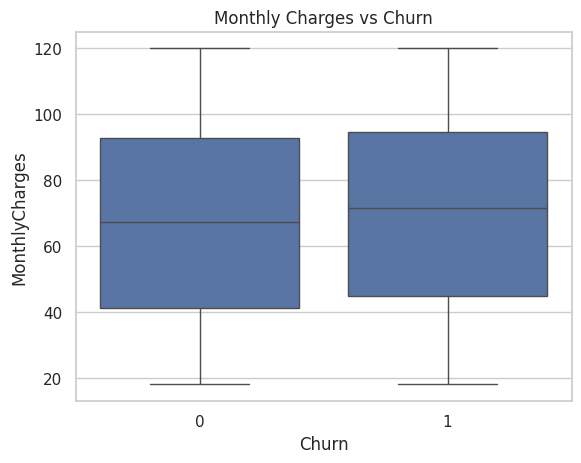

In [ ]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

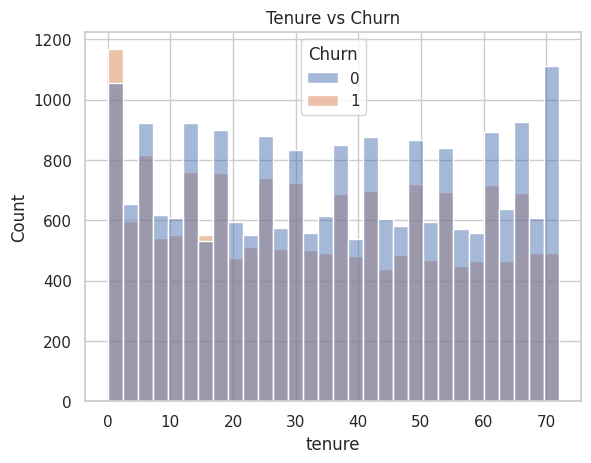

In [ ]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=30)
plt.title("Tenure vs Churn")
plt.show()

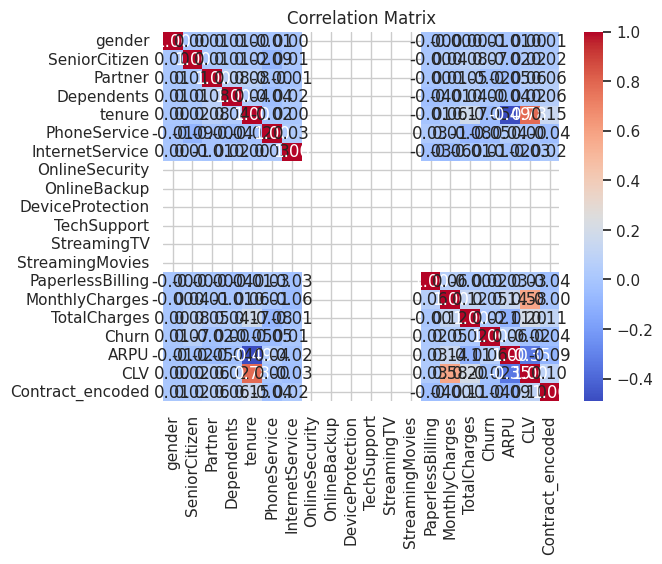

In [ ]:
corr_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Text(0.5, 1.0, 'Churn by Contract Type')

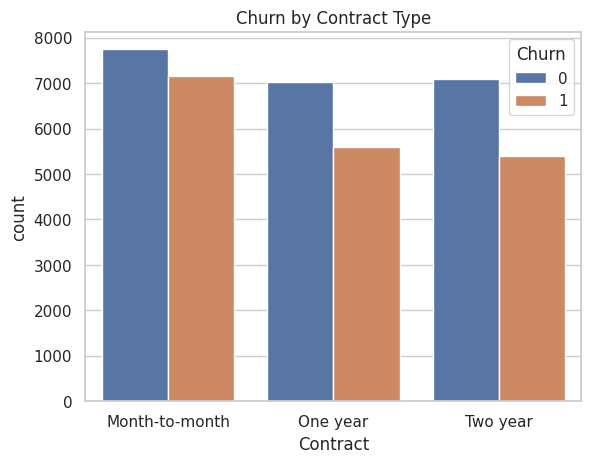

In [ ]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")

Text(0.5, 1.0, 'Tenure vs Churn')

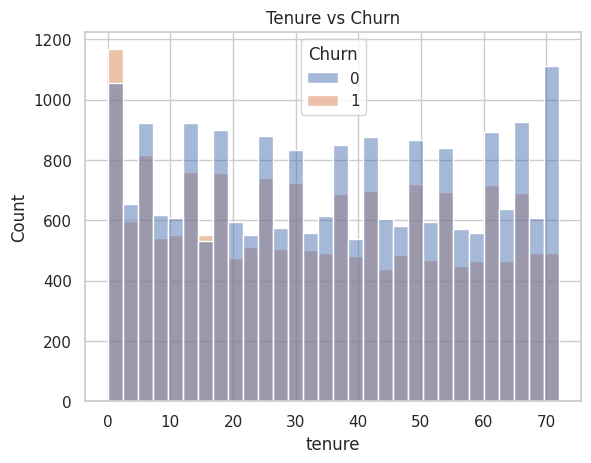

In [ ]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=30)
plt.title("Tenure vs Churn")

Text(0.5, 1.0, 'Monthly Charges vs Churn')

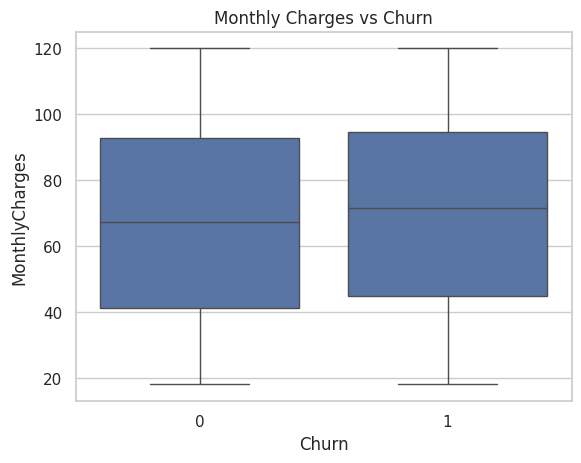

In [ ]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

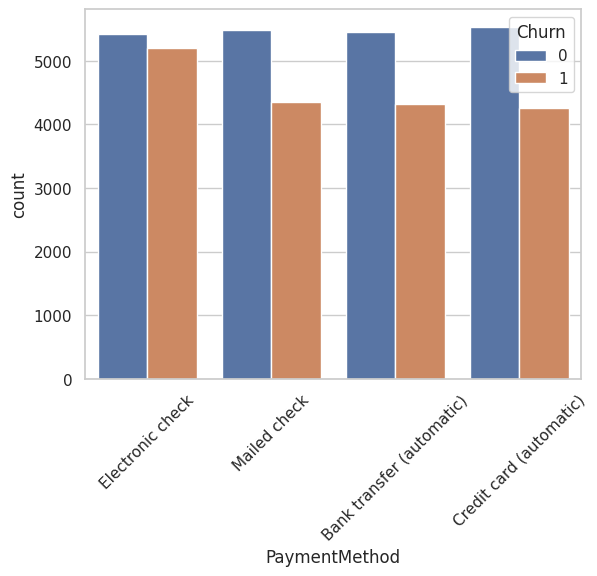

In [ ]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=45)

In [ ]:
df.to_csv("cleaned_churn_data.csv", index=False)